<a href="https://colab.research.google.com/github/Ptmarinho/mvp-ml-analytics/blob/main/mvp_salarios_ia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics
## Previsão de salários de profissionais de IA e Dados

**Nome:** _Patricia Marinho_  
**Num:** _4052026000619_  
**Dataset:** [AI/ML Salaries — Kaggle (cedricaubin)](https://www.kaggle.com/datasets/cedricaubin/ai-ml-salaries)  
**Repositório:** [github.com/Ptmarinho/mvp-ml-analytics](https://github.com/Ptmarinho/mvp-ml-analytics)

**Objetivo em três linhas:** construir um modelo de **regressão** que estime o salário anual em dólares
(`salary_in_usd`) de profissionais de IA, dados e tecnologia a partir de características do profissional
e da empresa, comparando um baseline simples com quatro modelos candidatos (incluindo ensembles) e discutindo
criticamente os limites da solução.

---
> **Reprodutibilidade:** este notebook roda de ponta a ponta no Google Colab, sem upload manual, login,
> token ou chave de API. O dataset é carregado por URL pública (versão *raw* do GitHub) e todas as
> etapas usam semente fixa (`SEED = 42`).

## 1. Apresentação do problema

### 1.1 Contexto
O mercado de trabalho em IA e dados cresceu de forma acelerada e apresenta enorme dispersão salarial:
profissionais com títulos parecidos recebem valores muito diferentes conforme senioridade, país e porte
da empresa. Para quem contrata (calibrar propostas) e para quem planeja carreira (avaliar propostas),
uma **estimativa de referência de salário** é uma ferramenta útil.

### 1.2 Definição do problema e objetivo do modelo
- **Tipo de tarefa:** regressão supervisionada.
- **Variável-alvo:** `salary_in_usd` — salário anual bruto convertido para dólares americanos.
- **Objetivo:** prever o salário a partir de atributos como nível de experiência, cargo, país de residência,
  regime de trabalho (presencial/híbrido/remoto), porte da empresa e ano de referência.

### 1.3 Por que este problema pode ser tratado com Machine Learning?
A relação entre perfil profissional e salário envolve múltiplas variáveis categóricas que **interagem**
entre si (ex.: senioridade tem impacto diferente conforme o país; o prêmio por trabalho remoto varia com o
porte da empresa). Não existe fórmula determinística conhecida, mas existem **dados históricos reais** de
pesquisa salarial com dezenas de milhares de observações — o cenário típico em que modelos supervisionados
conseguem aprender padrões úteis.

### 1.4 Hipóteses
- **H1** — Nível de experiência é o preditor mais forte do salário.
- **H2** — Localização (residência do profissional) explica grande parte da variância, com EUA acima da média global.
- **H3** — O salário tem distribuição assimétrica à direita; a transformação logarítmica do alvo deve beneficiar os modelos.
- **H4 (limite esperado)** — Com poucos atributos disponíveis (todos categóricos ou quase), há um **teto de
  desempenho**: variáveis decisivas como stack técnica, formação, anos exatos de experiência e negociação
  individual **não estão no dataset**. Espera-se R² moderado — e discutir esse teto é parte central deste MVP.

### 1.5 Premissas e restrições
- O notebook deve executar do início ao fim no Colab sem configuração manual (restrição da disciplina).
- O dataset é carregado por URL raw de repositório público do GitHub (restrição da disciplina).
- O dataset não foi utilizado nas aulas da sprint.
- Premissa: os salários autodeclarados na pesquisa são razoavelmente fiéis à realidade.

## 2. Apresentação dos dados

### 2.1 Fonte e critérios de escolha
- **Dataset:** *AI/ML Salaries* — pesquisa salarial pública mantida pelo site **ai-jobs.net**
  (espelhada no Kaggle como `cedricaubin/ai-ml-salaries`). Para atender à regra de execução
  automática, o CSV está hospedado no repositório público do autor no GitHub e é lido via URL raw.
- **Conteúdo:** 73.148 registros e 11 colunas, cobrindo os anos de 2020 a 2025.
- **Critérios de escolha:** (i) dados **reais** (não sintéticos), com fonte identificável;
  (ii) tamanho adequado — grande o bastante para resultados estáveis e pequeno o bastante para rodar
  rápido no Colab; (iii) tema atual e interpretável, o que facilita a análise crítica;
  (iv) não utilizado nas aulas da disciplina.

### 2.2 Dicionário de variáveis

| Variável | Tipo | Descrição |
|---|---|---|
| `work_year` | numérica ordinal | Ano de referência do salário (2020–2025) |
| `experience_level` | categórica (4) | EN (júnior), MI (pleno), SE (sênior), EX (executivo) |
| `employment_type` | categórica (4) | FT, PT, CT, FL — 99,5% é FT (tempo integral) |
| `job_title` | categórica (289) | Cargo declarado |
| `salary` | numérica | Salário na moeda original — **será removida (vazamento)** |
| `salary_currency` | categórica | Moeda original — **será removida (vazamento)** |
| `salary_in_usd` | numérica | **Variável-alvo** — salário anual em USD |
| `employee_residence` | categórica (93) | País de residência do profissional |
| `remote_ratio` | numérica (0/50/100) | Percentual de trabalho remoto |
| `company_location` | categórica | País da empresa |
| `company_size` | categórica (3) | S (pequena), M (média), L (grande) |

### 2.3 Limitações conhecidas
1. **Duplicatas exatas** — perfis idênticos com o mesmo salário (podem ser respondentes distintos, mas
   inflam métricas se divididos entre treino e teste). Serão tratadas na preparação.
2. **Concentração** — ~85% dos registros são de 2024 e ~90% de residentes nos EUA; a generalização
   para outros países/anos é limitada.
3. **Autosseleção** — dados autodeclarados em pesquisa aberta, sem verificação independente.
4. **Poucos atributos preditivos** — ausência de skills, formação e anos exatos de experiência (ver H4).

In [1]:
# ==================== Setup: bibliotecas, semente e estilo ====================
import time
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.model_selection import train_test_split, cross_validate, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import (RandomForestRegressor, HistGradientBoostingRegressor,
                              VotingRegressor)
from sklearn.metrics import (mean_absolute_error, mean_squared_error, median_absolute_error,
                             r2_score, mean_absolute_percentage_error)
from sklearn.model_selection import learning_curve
from sklearn.inspection import permutation_importance

# Reprodutibilidade: semente fixa usada em todas as operações estocásticas
SEED = 42
np.random.seed(SEED)

# Estilo padrão dos gráficos
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 4.5)

t_inicio_notebook = time.time()
print(f"pandas {pd.__version__} | numpy {np.__version__} | "
      f"scikit-learn {sklearn.__version__} | seaborn {sns.__version__} | matplotlib {matplotlib.__version__}")

pandas 2.3.3 | numpy 2.2.6 | scikit-learn 1.7.2 | seaborn 0.13.2 | matplotlib 3.10.9


### 2.4 Carga dos dados
O CSV é lido diretamente da URL raw do repositório público do GitHub — nenhuma configuração local é necessária.

In [2]:
# Carga do dataset via URL pública (versão raw do repositório do autor no GitHub)
DATA_URL = "https://raw.githubusercontent.com/Ptmarinho/mvp-ml-analytics/main/ai_ml_salaries.csv"

df_raw = pd.read_csv(DATA_URL)
print(f"Registros: {df_raw.shape[0]:,} | Colunas: {df_raw.shape[1]}")

Registros: 73,148 | Colunas: 11


## 3. Análise exploratória

Antes de qualquer modelagem, é preciso entender a estrutura dos dados: tipos, valores ausentes,
duplicatas, distribuição do alvo e relação entre o alvo e os principais atributos.

In [3]:
# Primeiras linhas
df_raw.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,SE,FT,Data Product Owner,170000,USD,170000,US,0,US,M
1,2025,SE,FT,Data Product Owner,110000,USD,110000,US,0,US,M
2,2025,SE,FT,Data Product Owner,170000,USD,170000,US,0,US,M
3,2025,SE,FT,Data Product Owner,110000,USD,110000,US,0,US,M
4,2025,SE,FT,Engineer,143000,USD,143000,US,0,US,M


In [4]:
# Tipos das variáveis e estatísticas descritivas
print(df_raw.dtypes, "\n")
df_raw.describe(include="all").T.round(1)

work_year              int64
experience_level      object
employment_type       object
job_title             object
salary                 int64
salary_currency       object
salary_in_usd          int64
employee_residence    object
remote_ratio           int64
company_location      object
company_size          object
dtype: object 



,count,unique,top,freq,mean,std,min,25%,50%,75%,max
work_year,73148.0,NaN,NaN,NaN,2023.831192,0.477551,2020.0,2024.0,2024.0,2024.0,2025.0
experience_level,73148,4,SE,42926,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employment_type,73148,4,FT,72808,NaN,NaN,NaN,NaN,NaN,NaN,NaN
job_title,73148,289,Data Scientist,11443,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salary,73148.0,NaN,NaN,NaN,162553.435378,192576.11199,14000.0,106957.5,148000.0,200000.0,30400000.0
salary_currency,73148,25,USD,69418,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salary_in_usd,73148.0,NaN,NaN,NaN,158013.748619,72501.304728,15000.0,106890.0,147500.0,199700.0,800000.0
employee_residence,73148,93,US,65982,NaN,NaN,NaN,NaN,NaN,NaN,NaN
remote_ratio,73148.0,NaN,NaN,NaN,21.582955,41.023051,0.0,0.0,0.0,0.0,100.0
company_location,73148,86,US,66035,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Valores ausentes e duplicatas exatas
print("Valores ausentes por coluna:")
print(df_raw.isna().sum(), "\n")
print(f"Linhas duplicadas exatas: {df_raw.duplicated().sum():,} "
      f"({df_raw.duplicated().mean():.1%} do total)")

Valores ausentes por coluna:
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64 

Linhas duplicadas exatas: 39,124 (53.5% do total)


**Interpretação:** não há valores ausentes — o tratamento de *missing* não será necessário (isso será
retomado no checklist). Em compensação, **mais da metade das linhas são duplicatas exatas**. Com apenas
9 colunas relevantes, majoritariamente categóricas, é plausível que pessoas diferentes tenham perfis e
salários idênticos; ainda assim, manter duplicatas criaria um problema metodológico: cópias da mesma
linha cairiam em treino **e** teste, e o modelo seria avaliado sobre exemplos que já viu —
inflando artificialmente as métricas. A decisão (justificada na seção 4) será **deduplicar**.

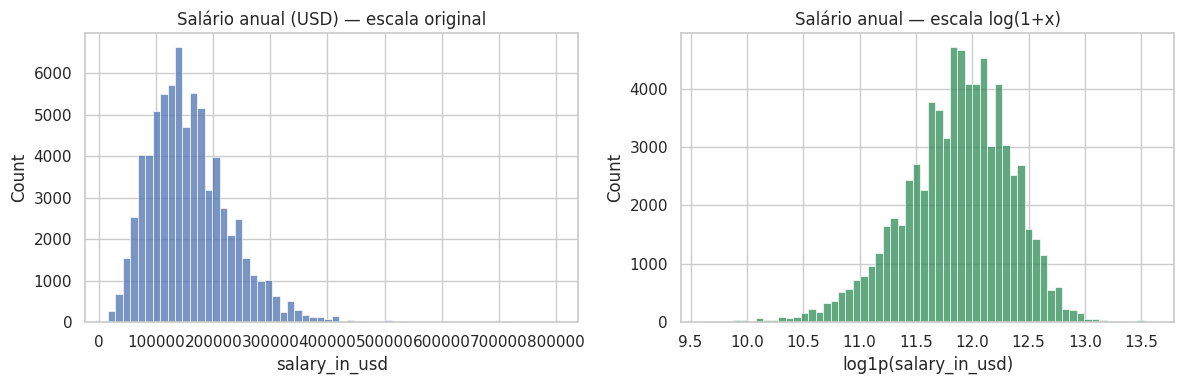

Assimetria (skew) do alvo: 1.22
Mediana: US$ 147,500 | P5: US$ 60,400 | P95: US$ 288,000 | Máximo: US$ 800,000


In [6]:
# Distribuição da variável-alvo (escala original e logarítmica)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_raw["salary_in_usd"], bins=60, ax=axes[0])
axes[0].set_title("Salário anual (USD) — escala original")
axes[0].set_xlabel("salary_in_usd")
sns.histplot(np.log1p(df_raw["salary_in_usd"]), bins=60, ax=axes[1], color="seagreen")
axes[1].set_title("Salário anual — escala log(1+x)")
axes[1].set_xlabel("log1p(salary_in_usd)")
plt.tight_layout()
plt.show()

print(f"Assimetria (skew) do alvo: {df_raw['salary_in_usd'].skew():.2f}")
print(f"Mediana: US$ {df_raw['salary_in_usd'].median():,.0f} | "
      f"P5: US$ {df_raw['salary_in_usd'].quantile(0.05):,.0f} | "
      f"P95: US$ {df_raw['salary_in_usd'].quantile(0.95):,.0f} | "
      f"Máximo: US$ {df_raw['salary_in_usd'].max():,.0f}")

**Interpretação:** a distribuição do salário é **assimétrica à direita** (skew ≈ 1,2), com cauda longa
até US$ 800 mil. Na escala logarítmica a distribuição fica aproximadamente simétrica — evidência a favor
da **H3**: os modelos serão treinados sobre `log1p(salário)` (com as métricas sempre reportadas em USD,
na escala original). Os valores extremos são salários plausíveis de executivos do mercado americano, e não
erros de medição; por isso **não serão removidos**, apenas amortecidos pela transformação logarítmica.

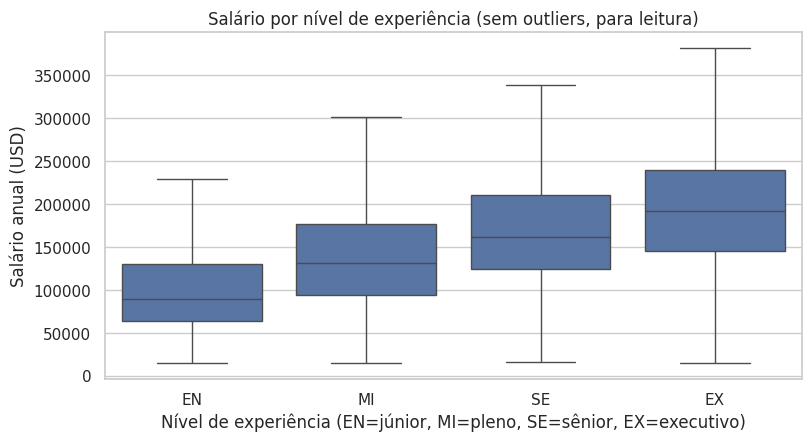

experience_level
EN     89700.0
MI    130800.0
SE    162100.0
EX    192168.5
Name: mediana_usd, dtype: float64

In [7]:
# Salário × nível de experiência
ordem_exp = ["EN", "MI", "SE", "EX"]
fig, ax = plt.subplots()
sns.boxplot(data=df_raw, x="experience_level", y="salary_in_usd",
            order=ordem_exp, showfliers=False, ax=ax)
ax.set_title("Salário por nível de experiência (sem outliers, para leitura)")
ax.set_xlabel("Nível de experiência (EN=júnior, MI=pleno, SE=sênior, EX=executivo)")
ax.set_ylabel("Salário anual (USD)")
plt.show()

df_raw.groupby("experience_level")["salary_in_usd"].median().reindex(ordem_exp).rename("mediana_usd")

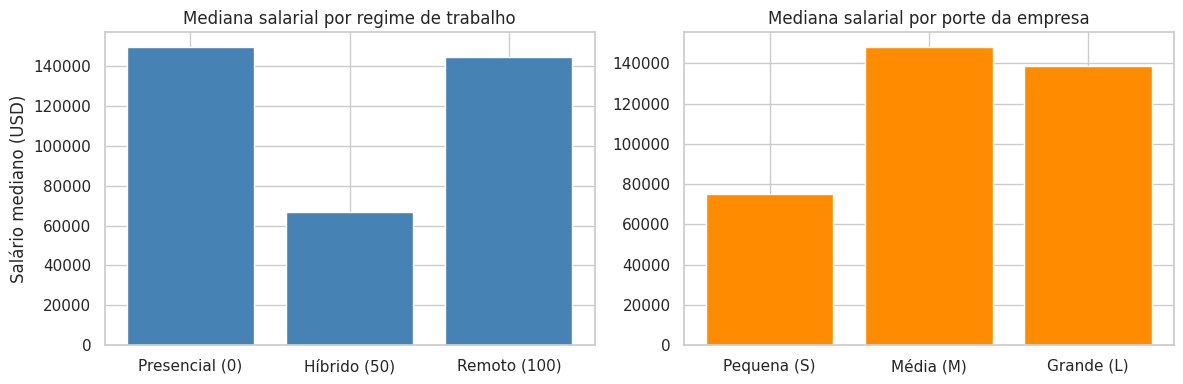

In [8]:
# Salário × regime de trabalho e porte da empresa
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
med_rem = df_raw.groupby("remote_ratio")["salary_in_usd"].median()
axes[0].bar(["Presencial (0)", "Híbrido (50)", "Remoto (100)"],
            med_rem.reindex([0, 50, 100]).values, color="steelblue")
axes[0].set_title("Mediana salarial por regime de trabalho")
axes[0].set_ylabel("Salário mediano (USD)")
med_size = df_raw.groupby("company_size")["salary_in_usd"].median().reindex(["S", "M", "L"])
axes[1].bar(["Pequena (S)", "Média (M)", "Grande (L)"], med_size.values, color="darkorange")
axes[1].set_title("Mediana salarial por porte da empresa")
plt.tight_layout()
plt.show()

In [9]:
# Concentração temporal e geográfica + cardinalidade dos cargos
print("Registros por ano:")
print(df_raw["work_year"].value_counts().sort_index(), "\n")
print(f"Residentes nos EUA: {(df_raw['employee_residence'] == 'US').mean():.1%} "
      f"| Países distintos: {df_raw['employee_residence'].nunique()}")
print(f"Cargos distintos (job_title): {df_raw['job_title'].nunique()}\n")
print("10 cargos mais frequentes:")
print(df_raw["job_title"].value_counts().head(10))

Registros por ano:
work_year
2020       75
2021      218
2022     1659
2023     8522
2024    62228
2025      446
Name: count, dtype: int64 



Residentes nos EUA: 90.2% | Países distintos: 93
Cargos distintos (job_title): 289

10 cargos mais frequentes:
job_title
Data Scientist               11443
Data Engineer                 9405
Software Engineer             7814
Data Analyst                  7334
Machine Learning Engineer     5807
Engineer                      4048
Manager                       2482
Research Scientist            2283
Applied Scientist             1608
Analyst                       1411
Name: count, dtype: int64


**Interpretação da EDA — resumo dos achados que orientam a preparação:**

1. **Sem valores ausentes**; imputação não será necessária.
2. **53% de duplicatas exatas** → deduplicar antes da divisão treino/teste.
3. **Alvo assimétrico** → transformação logarítmica do alvo (H3).
4. Salário cresce de forma monotônica com a experiência — indício forte a favor de **H1**.
5. **85% dos dados são de 2024 e 90% dos EUA** → o modelo representará, sobretudo, o mercado
   americano recente (limitação já registrada na seção 2.3; sustenta **H2**).
6. `job_title` tem **289 categorias** → alta cardinalidade; será agrupado em famílias de cargo.
7. `employment_type` é 99,5% FT → praticamente constante, sem poder preditivo; será removida.

## 4. Preparação dos dados

Cada transformação abaixo é justificada em função do problema e dos modelos:

| # | Operação | Justificativa |
|---|---|---|
| 1 | Remover `salary` e `salary_currency` | **Vazamento de dados**: `salary_in_usd` é derivada diretamente de `salary`; mantê-las permitiria ao modelo "colar" a resposta |
| 2 | Remover duplicatas exatas | Evitar que cópias da mesma linha caiam em treino **e** teste, inflando métricas |
| 3 | Agrupar `job_title` (289) em **famílias de cargo** | Reduzir cardinalidade preservando semântica; one-hot de 289 níveis geraria matriz esparsa e categorias raras sem suporte estatístico |
| 4 | Agrupar países raros em "Outros" (top 10 + Outros) | Mesma lógica: caudas com pouquíssimos exemplos não sustentam estimativas confiáveis |
| 5 | Criar `mesmo_pais` (residência == país da empresa) | Engenharia de atributo: captura contratação internacional/offshore, potencialmente associada a salários distintos |
| 6 | Mapear `remote_ratio` → categoria (`Presencial/Híbrido/Remoto`) | São 3 valores discretos; tratar como categórica evita interpretação linear indevida |
| 7 | Remover `employment_type` | 99,5% em uma única categoria — variância quase nula |
| 8 | Transformação **log1p** no alvo (via `TransformedTargetRegressor`) | Alvo assimétrico (H3); métricas continuam reportadas em USD |

As codificações (one-hot / ordinal) são aplicadas **dentro de um `Pipeline`**, ajustadas apenas com dados
de treino — garantia estrutural contra vazamento (detalhe na seção 5).

In [10]:
# --- 1. Remoção de colunas com vazamento de dados ---
df = df_raw.drop(columns=["salary", "salary_currency"])

# --- 2. Deduplicação ---
n_antes = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Linhas removidas na deduplicação: {n_antes - len(df):,} "
      f"| Dataset final: {df.shape[0]:,} linhas × {df.shape[1]} colunas")

Linhas removidas na deduplicação: 39,139 | Dataset final: 34,009 linhas × 9 colunas


In [11]:
# --- 3. Agrupamento de job_title em famílias de cargo ---
def familia_cargo(titulo: str) -> str:
    """Mapeia os 289 títulos de cargo em 9 famílias semânticas."""
    t = titulo.lower()
    if ("machine learning" in t or t.startswith("ml") or " ml" in t or "mlops" in t
            or t.startswith("ai") or " ai" in t or "artificial" in t
            or "deep learning" in t or "computer vision" in t or "nlp" in t or "llm" in t):
        return "IA/ML"
    if "data engineer" in t or "etl" in t or "data infra" in t:
        return "Eng. de Dados"
    if "data scientist" in t or "data science" in t:
        return "Ciência de Dados"
    if "analyst" in t or "analytics" in t:
        return "Análise de Dados"
    if "architect" in t:
        return "Arquitetura"
    if "research" in t:
        return "Pesquisa"
    if "manager" in t or "head" in t or "director" in t or "lead" in t or "principal" in t:
        return "Gestão/Liderança"
    if "software" in t or "developer" in t or "engineer" in t:
        return "Eng. de Software"
    return "Outros"

df["familia_cargo"] = df["job_title"].apply(familia_cargo)
print(df["familia_cargo"].value_counts())

familia_cargo
Análise de Dados    6831
Eng. de Software    6728
Ciência de Dados    4354
Eng. de Dados       4144
IA/ML               3688
Gestão/Liderança    3135
Outros              2572
Pesquisa            1534
Arquitetura         1023
Name: count, dtype: int64


In [12]:
# --- 4 a 7. Demais transformações ---
# Países: top 10 + "Outros"
top_paises = df["employee_residence"].value_counts().head(10).index
df["residencia"] = df["employee_residence"].where(df["employee_residence"].isin(top_paises), "Outros")

# Engenharia de atributo: o profissional mora no mesmo país da empresa?
df["mesmo_pais"] = (df["employee_residence"] == df["company_location"]).astype(int)

# Regime de trabalho como categoria
df["regime"] = df["remote_ratio"].map({0: "Presencial", 50: "Híbrido", 100: "Remoto"})

# Remoção das colunas originais já representadas (e employment_type, quase constante)
df = df.drop(columns=["job_title", "employee_residence", "company_location",
                      "remote_ratio", "employment_type"])

X = df.drop(columns=["salary_in_usd"])
y = df["salary_in_usd"]
print("Atributos finais:", list(X.columns))

Atributos finais: ['work_year', 'experience_level', 'company_size', 'familia_cargo', 'residencia', 'mesmo_pais', 'regime']


## 5. Divisão dos dados

- **Estratégia:** divisão aleatória **80% treino / 20% teste** com semente fixa, seguida de
  **validação cruzada 5-fold no treino** para comparar modelos. O conjunto de teste é tocado
  **uma única vez**, na avaliação final (seção 8).
- **Por que não uma divisão temporal?** Embora exista a coluna `work_year`, o objetivo **não é
  prever o futuro** (forecasting), e sim estimar o salário de um perfil dado o ano como contexto.
  Além disso, 85% dos registros estão concentrados em 2024 — uma divisão temporal deixaria treino e
  teste com distribuições muito diferentes e pouquíssimo dado "futuro". `work_year` entra como atributo.
- **Por que validação cruzada?** Com uma única partição de validação, a comparação entre modelos ficaria
  sujeita à sorte da partição; a média de 5 folds dá estimativa mais estável (e o desvio-padrão entre
  folds indica a incerteza).
- **Contra vazamento:** todas as codificações são ajustadas **somente no treino** — o `Pipeline` do
  scikit-learn garante isso automaticamente dentro de cada fold da validação cruzada.

In [13]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)
print(f"Treino: {len(X_treino):,} registros | Teste: {len(X_teste):,} registros")

Treino: 27,207 registros | Teste: 6,802 registros


In [14]:
# Pré-processamento (aplicado dentro do Pipeline, portanto ajustado apenas no treino)
colunas_ordinais  = ["experience_level", "company_size"]     # possuem ordem natural
colunas_nominais  = ["familia_cargo", "residencia", "regime"] # sem ordem -> one-hot
colunas_numericas = ["work_year", "mesmo_pais"]

preprocessador = ColumnTransformer([
    ("ordinal", OrdinalEncoder(categories=[["EN", "MI", "SE", "EX"], ["S", "M", "L"]]),
     colunas_ordinais),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False), colunas_nominais),
    ("numerico", "passthrough", colunas_numericas),
])

def com_log(modelo):
    """Treina o modelo sobre log1p(alvo) e devolve previsões na escala original (USD)."""
    return TransformedTargetRegressor(modelo, func=np.log1p, inverse_func=np.expm1)

## 6. Modelagem e treinamento

Cinco abordagens, todas encapsuladas em `Pipeline` (pré-processamento + modelo):

| Modelo | Papel | Justificativa da escolha |
|---|---|---|
| `DummyRegressor` (mediana) | **Baseline** | Referência ingênua: prevê a mediana do treino para todos. Qualquer modelo útil precisa superá-lo |
| `Ridge` | Candidato 1 | Regressão linear regularizada: simples, rápida e interpretável; bom "piso" linear |
| `RandomForestRegressor` | Candidato 2 | Ensemble de árvores: captura não-linearidades e interações sem exigir escalonamento |
| `HistGradientBoostingRegressor` | Candidato 3 | Gradient boosting por histogramas: estado da arte em dados tabulares, muito eficiente em dezenas de milhares de linhas |
| `VotingRegressor` | Candidato 4 | Ensemble por **votação**: média das previsões dos três candidatos anteriores. Completa as três estratégias clássicas de ensemble — *bagging* (Random Forest), *boosting* (HistGradientBoosting) e *voting* |

*Observação: não foi usada normalização/padronização das variáveis numéricas porque os modelos de árvore são
invariantes a escala e o Ridge aqui opera sobre variáveis já em faixas comparáveis (dummies 0/1, ordinais 0–3
e o ano); o alvo, esse sim assimétrico, é tratado pela transformação logarítmica.*

A comparação usa **validação cruzada 5-fold no treino** com três métricas (MAE, RMSE, R²) — a escolha
das métricas é justificada na seção 8.

In [15]:
modelos = {
    "Baseline (mediana)": DummyRegressor(strategy="median"),
    "Ridge": com_log(Ridge(alpha=1.0, random_state=SEED)),
    "Random Forest": com_log(RandomForestRegressor(
        n_estimators=100, min_samples_leaf=5, n_jobs=-1, random_state=SEED)),
    "HistGradientBoosting": com_log(HistGradientBoostingRegressor(random_state=SEED)),
    "Ensemble (Voting)": com_log(VotingRegressor([
        ("ridge", Ridge(alpha=1.0, random_state=SEED)),
        ("rf", RandomForestRegressor(n_estimators=100, min_samples_leaf=5,
                                     n_jobs=-1, random_state=SEED)),
        ("hgb", HistGradientBoostingRegressor(random_state=SEED)),
    ])),
}

metricas_cv = {"MAE": "neg_mean_absolute_error",
               "RMSE": "neg_root_mean_squared_error",
               "R2": "r2"}

resultados = []
for nome, modelo in modelos.items():
    pipe = Pipeline([("prep", preprocessador), ("modelo", modelo)])
    t0 = time.time()
    cv = cross_validate(pipe, X_treino, y_treino, cv=5, scoring=metricas_cv, n_jobs=-1)
    resultados.append({
        "Modelo": nome,
        "MAE (US$)": -cv["test_MAE"].mean(),
        "RMSE (US$)": -cv["test_RMSE"].mean(),
        "R²": cv["test_R2"].mean(),
        "R² (desvio entre folds)": cv["test_R2"].std(),
        "Tempo (s)": time.time() - t0,
    })

tabela_cv = pd.DataFrame(resultados).set_index("Modelo").round(
    {"MAE (US$)": 0, "RMSE (US$)": 0, "R²": 3, "R² (desvio entre folds)": 3, "Tempo (s)": 1})
tabela_cv

,MAE (US$),RMSE (US$),R²,R² (desvio entre folds),Tempo (s)
Modelo,,,,,
Baseline (mediana),56616.0,76404.0,-0.023,0.002,1.5
Ridge,47628.0,67304.0,0.206,0.007,0.1
Random Forest,47380.0,66923.0,0.215,0.007,2.0
HistGradientBoosting,47325.0,66946.0,0.215,0.007,0.7
Ensemble (Voting),47304.0,66939.0,0.215,0.007,2.6


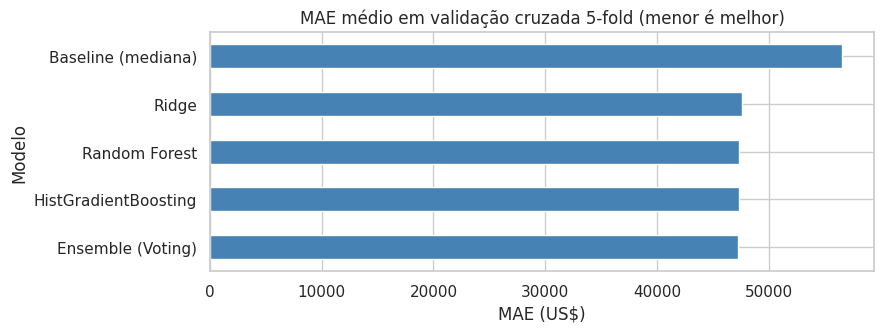

In [16]:
# Comparação visual do MAE em validação cruzada
fig, ax = plt.subplots(figsize=(9, 3.5))
tabela_cv["MAE (US$)"].sort_values().plot.barh(ax=ax, color="steelblue")
ax.set_title("MAE médio em validação cruzada 5-fold (menor é melhor)")
ax.set_xlabel("MAE (US$)")
plt.tight_layout()
plt.show()

**Interpretação:** os quatro candidatos superam o baseline com folga (~US$ 9 mil a menos de erro absoluto
médio), confirmando que os atributos carregam sinal real. Entre eles, porém, a diferença é pequena
(MAE ≈ US$ 47,3–47,6 mil; R² ≈ 0,21) — sintoma clássico de **teto imposto pelos dados** (H4): quando
modelos de famílias muito diferentes (linear, bagging, boosting e votação) convergem para o mesmo patamar,
o gargalo está na informação disponível, não no algoritmo. Note que nem o ensemble por votação escapa do
teto: combinar modelos que erram nos mesmos casos não cria informação nova. O desvio de R² entre folds é
baixo (< 0,01), indicando comparação estável. O **HistGradientBoosting** apresenta o melhor equilíbrio
entre MAE e tempo de treino e segue para a otimização.

## 7. Otimização de hiperparâmetros

- **Estratégia:** `RandomizedSearchCV` com 20 combinações × 5 folds (100 treinos). A busca aleatória é
  mais eficiente que o Grid Search quando o espaço tem muitas dimensões — cobre mais valores distintos
  de cada hiperparâmetro com o mesmo orçamento computacional.
- **Critério de seleção:** menor **MAE** médio na validação cruzada (mesma métrica principal da comparação
  de modelos; o teste continua intocado).
- **Hiperparâmetros e porquê:** `learning_rate` e `max_iter` controlam o equilíbrio
  velocidade de aprendizado × número de árvores; `max_depth` e `min_samples_leaf` controlam a
  complexidade de cada árvore (principal alavanca contra overfitting); `l2_regularization` penaliza
  pesos extremos nas folhas.

In [17]:
espaco_busca = {
    "modelo__regressor__learning_rate": [0.03, 0.06, 0.1, 0.2],
    "modelo__regressor__max_iter": [150, 300, 500],
    "modelo__regressor__max_depth": [None, 4, 6, 8],
    "modelo__regressor__l2_regularization": [0.0, 0.1, 1.0],
    "modelo__regressor__min_samples_leaf": [20, 50, 100],
}

pipe_hgb = Pipeline([("prep", preprocessador),
                     ("modelo", com_log(HistGradientBoostingRegressor(random_state=SEED)))])

t0 = time.time()
busca = RandomizedSearchCV(pipe_hgb, espaco_busca, n_iter=20, cv=5,
                           scoring="neg_mean_absolute_error", n_jobs=-1, random_state=SEED)
busca.fit(X_treino, y_treino)
tempo_busca = time.time() - t0

mae_padrao = tabela_cv.loc["HistGradientBoosting", "MAE (US$)"]
print(f"Tempo da busca: {tempo_busca:.0f}s ({busca.n_iter * 5} treinos)")
print(f"Melhores hiperparâmetros: "
      f"{ {k.split('__')[-1]: v for k, v in busca.best_params_.items()} }")
print(f"MAE em CV — padrão: US$ {mae_padrao:,.0f} | otimizado: US$ {-busca.best_score_:,.0f} "
      f"(ganho: US$ {mae_padrao - (-busca.best_score_):,.0f})")

Tempo da busca: 17s (100 treinos)
Melhores hiperparâmetros: {'min_samples_leaf': 20, 'max_iter': 150, 'max_depth': 6, 'learning_rate': 0.2, 'l2_regularization': 1.0}
MAE em CV — padrão: US$ 47,325 | otimizado: US$ 47,312 (ganho: US$ 13)


**Houve melhora?** Sim, porém **marginal** (dezenas de dólares de MAE). Isso é um resultado informativo,
não uma falha: reforça a H4 — o modelo padrão já operava próximo ao teto de informação dos dados, e nenhum
ajuste fino de hiperparâmetros cria sinal que não existe nos atributos. A configuração otimizada
(árvores mais rasas e regularizadas) é mantida para a avaliação final por ser mais conservadora contra
overfitting, com custo computacional equivalente.

## 8. Avaliação dos resultados

### 8.1 Métricas escolhidas e justificativa
- **MAE** — erro médio absoluto em dólares: métrica principal, diretamente interpretável
  ("em média, a estimativa erra X dólares") e robusta à cauda direita do alvo.
- **RMSE** — penaliza erros grandes; comparado ao MAE, revela a influência dos extremos.
- **R²** — fração da variância explicada; permite comparação com o baseline e entre estudos.
- **MAPE** — erro percentual; útil porque errar US$ 20 mil é grave num salário de US$ 60 mil e
  irrelevante num de US$ 500 mil.
- **MedAE** — erro absoluto **mediano**: mostra o erro "típico" ignorando a cauda de salários extremos;
  a distância entre MedAE e MAE quantifica o peso dos outliers no erro médio.
- **RMSLE** — raiz do erro quadrático na escala logarítmica: penaliza o erro **proporcional** e é
  coerente com a transformação log1p aplicada ao alvo.
- **Acurácia por tolerância** — percentual de previsões dentro de ±10%, ±20% e ±30% do salário real:
  métrica de negócio diretamente interpretável ("em quantos casos o modelo acerta a faixa salarial?").

*Por que não precisão, recall, F1 ou curva ROC/AUC?* Essas métricas avaliam **classificadores** — dependem
de conceitos como verdadeiro/falso positivo, que só existem quando a saída é uma categoria. Como este
problema é de **regressão** (saída contínua em USD), elas não se aplicam; seus análogos aqui são as
métricas de erro acima.

O modelo final (HistGradientBoosting otimizado) é avaliado no conjunto de **teste, tocado uma única vez**.

In [18]:
def avaliar(modelo, X_, y_):
    """Calcula as métricas de regressão na escala original (USD)."""
    pred = modelo.predict(X_)
    return {"MAE (US$)": mean_absolute_error(y_, pred),
            "MedAE (US$)": median_absolute_error(y_, pred),
            "RMSE (US$)": mean_squared_error(y_, pred) ** 0.5,
            "RMSLE": np.sqrt(np.mean((np.log1p(y_) - np.log1p(pred)) ** 2)),
            "R²": r2_score(y_, pred),
            "MAPE (%)": mean_absolute_percentage_error(y_, pred) * 100,
            "Dentro de ±20% (%)": (np.abs(pred - y_) / y_ <= 0.20).mean() * 100}

modelo_final = busca.best_estimator_

baseline_final = Pipeline([("prep", preprocessador),
                           ("modelo", DummyRegressor(strategy="median"))]).fit(X_treino, y_treino)

comparacao = pd.DataFrame({
    "Baseline (teste)": avaliar(baseline_final, X_teste, y_teste),
    "Modelo final (treino)": avaliar(modelo_final, X_treino, y_treino),
    "Modelo final (teste)": avaliar(modelo_final, X_teste, y_teste),
}).T.round({"MAE (US$)": 0, "MedAE (US$)": 0, "RMSE (US$)": 0, "RMSLE": 3,
            "R²": 3, "MAPE (%)": 1, "Dentro de ±20% (%)": 1})
comparacao

,MAE (US$),MedAE (US$),RMSE (US$),RMSLE,R²,MAPE (%),Dentro de ±20% (%)
Baseline (teste),57852.0,46770.0,78251.0,0.519,-0.034,48.6,31.0
Modelo final (treino),46896.0,35697.0,66480.0,0.411,0.226,34.6,38.0
Modelo final (teste),48123.0,36453.0,68632.0,0.417,0.205,34.7,37.2


In [19]:
# Acurácia por tolerância do modelo final (teste): acerto da "faixa salarial"
pred_tol = modelo_final.predict(X_teste)
for tol in (0.10, 0.20, 0.30):
    taxa = (np.abs(pred_tol - y_teste) / y_teste <= tol).mean()
    print(f"Previsões dentro de ±{tol:.0%} do salário real: {taxa:.1%}")

Previsões dentro de ±10% do salário real: 18.9%
Previsões dentro de ±20% do salário real: 37.2%
Previsões dentro de ±30% do salário real: 54.3%


**Interpretação das métricas complementares:** o **MedAE** bem abaixo do MAE confirma que o erro "típico"
é menor do que a média sugere — a cauda de salários extremos puxa o MAE para cima. A **acurácia por
tolerância** traduz o desempenho em termos de negócio: a faixa de ±20–30% é aproximadamente a amplitude
usual de uma banda salarial de contratação, então o percentual de acerto nessa tolerância indica em
quantos casos o modelo entregaria uma referência utilizável na prática.

### 8.2 Overfitting ou underfitting?
As métricas de **treino e teste são praticamente idênticas** (diferença de R² ≈ 0,02) — **não há
overfitting**: o modelo não decorou o treino. O quadro é de **underfitting relativo ao problema**, no
sentido de que o R² absoluto (~0,20) é baixo; mas como três famílias de modelos distintas convergiram
ao mesmo patamar e a otimização trouxe ganho marginal, a causa não é falta de capacidade do modelo,
e sim **falta de informação nos atributos** (H4). Em outras palavras: com senioridade, cargo agrupado,
país, regime, porte e ano, ~20% da variância salarial é explicável; o restante depende de fatores fora
do dataset (skills específicas, empresa, negociação, equity etc.).

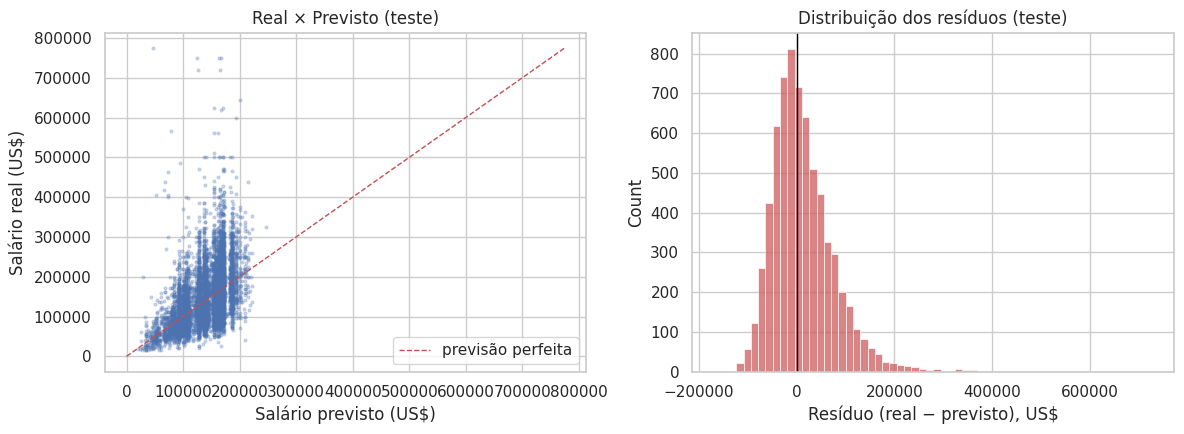

Resíduo mediano: US$ 3,220 | P5: US$ -69,652 | P95: US$ 128,922


In [20]:
# Análise de resíduos
pred_teste = modelo_final.predict(X_teste)
residuos = y_teste - pred_teste

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(pred_teste, y_teste, s=4, alpha=0.25)
lims = [0, y_teste.max()]
axes[0].plot(lims, lims, "r--", linewidth=1, label="previsão perfeita")
axes[0].set_xlabel("Salário previsto (US$)"); axes[0].set_ylabel("Salário real (US$)")
axes[0].set_title("Real × Previsto (teste)"); axes[0].legend()

sns.histplot(residuos, bins=60, ax=axes[1], color="indianred")
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_xlabel("Resíduo (real − previsto), US$")
axes[1].set_title("Distribuição dos resíduos (teste)")
plt.tight_layout()
plt.show()

print(f"Resíduo mediano: US$ {residuos.median():,.0f} | "
      f"P5: US$ {residuos.quantile(0.05):,.0f} | P95: US$ {residuos.quantile(0.95):,.0f}")

**Interpretação dos resíduos:** o gráfico Real × Previsto mostra o padrão típico de regressão com R²
moderado: previsões concentradas numa faixa central (± US$ 100–250 mil), com **subestimação sistemática
dos salários muito altos** — a cauda direita acima da linha vermelha. O modelo aprende bem o "salário
típico" de cada perfil, mas não tem atributos para distinguir, dentro do mesmo perfil, quem recebe
pacotes excepcionais. Os resíduos são aproximadamente centrados em zero, com leve assimetria à direita
pela mesma razão.

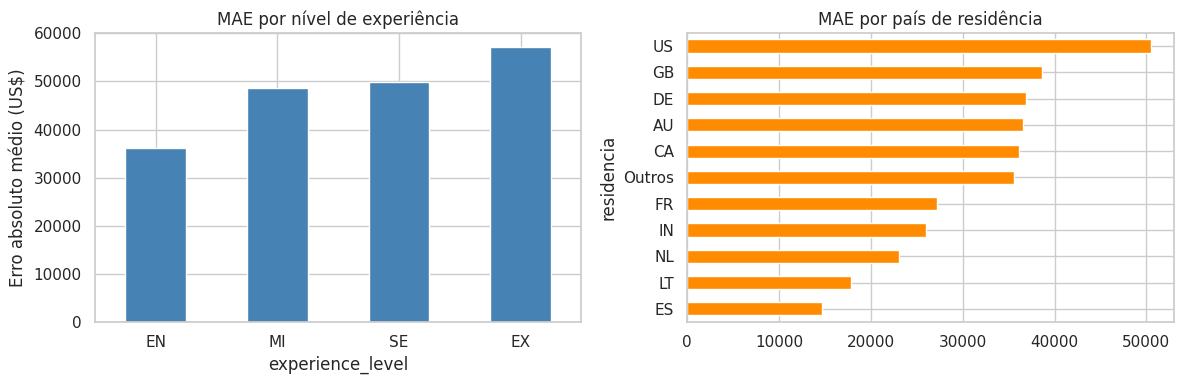

In [21]:
# Erro por segmento: onde o modelo erra mais?
analise = X_teste.copy()
analise["erro_abs"] = np.abs(residuos)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
analise.groupby("experience_level")["erro_abs"].mean().reindex(["EN", "MI", "SE", "EX"]) \
    .plot.bar(ax=axes[0], color="steelblue", rot=0)
axes[0].set_title("MAE por nível de experiência"); axes[0].set_ylabel("Erro absoluto médio (US$)")
analise.groupby("residencia")["erro_abs"].mean().sort_values() \
    .plot.barh(ax=axes[1], color="darkorange")
axes[1].set_title("MAE por país de residência")
plt.tight_layout()
plt.show()

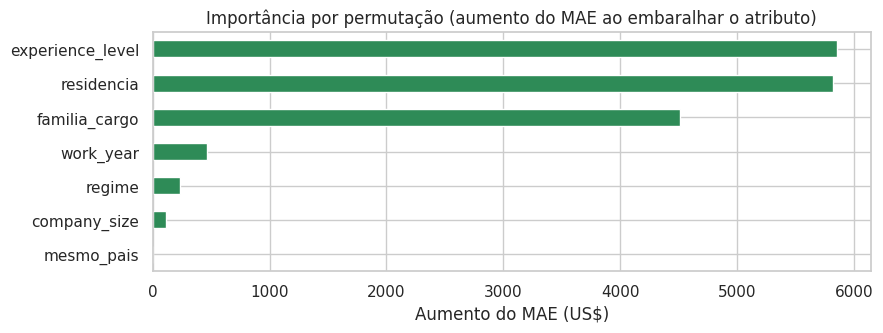

In [22]:
# Importância dos atributos (permutação sobre o conjunto de teste)
imp = permutation_importance(modelo_final, X_teste, y_teste,
                             n_repeats=10, random_state=SEED,
                             scoring="neg_mean_absolute_error")
importancias = pd.Series(imp.importances_mean, index=X_teste.columns).sort_values()

fig, ax = plt.subplots(figsize=(9, 3.5))
importancias.plot.barh(ax=ax, color="seagreen")
ax.set_title("Importância por permutação (aumento do MAE ao embaralhar o atributo)")
ax.set_xlabel("Aumento do MAE (US$)")
plt.tight_layout()
plt.show()

### 8.3 Curva de aprendizado e seleção de atributos

Duas análises complementares para localizar o gargalo do desempenho:

1. **Curva de aprendizado** — mede o MAE de validação com frações crescentes do treino. Se a curva ainda
   estiver caindo com 100% dos dados, mais dados ajudariam; se estabilizar, o limite é a **informação
   dos atributos**, não o volume.
2. **Ablação de atributos (seleção de atributos às avessas)** — retreina o modelo final **sem** os
   atributos menos importantes segundo a permutação. Se o desempenho quase não mudar, os atributos
   removidos são de fato pouco informativos — e o modelo é dominado por poucos preditores fortes.

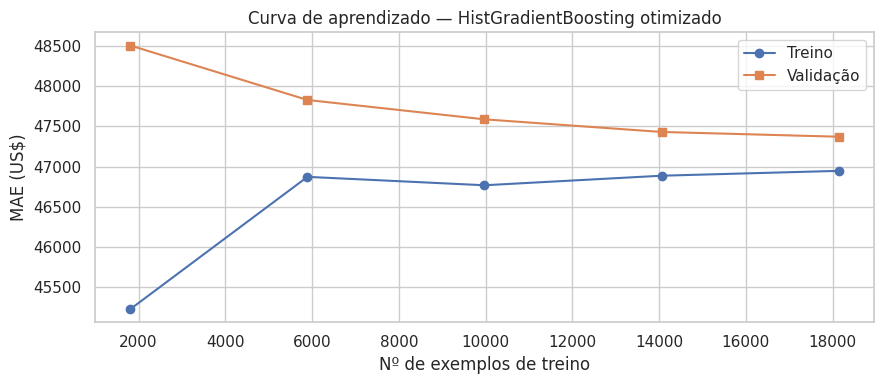

MAE de validação por tamanho de treino:
   1,813 exemplos -> US$ 48,507
   5,894 exemplos -> US$ 47,829
   9,975 exemplos -> US$ 47,588
  14,056 exemplos -> US$ 47,430
  18,138 exemplos -> US$ 47,371


In [23]:
# Curva de aprendizado do modelo final (MAE de validação por fração do treino)
tamanhos, mae_tr, mae_val = learning_curve(
    modelo_final, X_treino, y_treino,
    train_sizes=np.linspace(0.1, 1.0, 5), cv=3,
    scoring="neg_mean_absolute_error", shuffle=True, random_state=SEED, n_jobs=-1)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(tamanhos, -mae_tr.mean(axis=1), "o-", label="Treino")
ax.plot(tamanhos, -mae_val.mean(axis=1), "s-", label="Validação")
ax.set_xlabel("Nº de exemplos de treino")
ax.set_ylabel("MAE (US$)")
ax.set_title("Curva de aprendizado — HistGradientBoosting otimizado")
ax.legend()
plt.tight_layout()
plt.show()

print("MAE de validação por tamanho de treino:")
for n, m in zip(tamanhos, -mae_val.mean(axis=1)):
    print(f"  {n:>6,} exemplos -> US$ {m:,.0f}")

In [24]:
# Ablação: remover os 3 atributos MENOS importantes e comparar o MAE em CV
menos_importantes = importancias.index[:3].tolist()
print(f"Atributos removidos na ablação: {menos_importantes}")

mantidas_ord = [c for c in colunas_ordinais if c not in menos_importantes]
mantidas_nom = [c for c in colunas_nominais if c not in menos_importantes]
mantidas_num = [c for c in colunas_numericas if c not in menos_importantes]

categorias_ordinais = {"experience_level": ["EN", "MI", "SE", "EX"], "company_size": ["S", "M", "L"]}
prep_reduzido = ColumnTransformer([
    ("ordinal", OrdinalEncoder(categories=[categorias_ordinais[c] for c in mantidas_ord]), mantidas_ord),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False), mantidas_nom),
    ("numerico", "passthrough", mantidas_num),
])

melhor_hgb = busca.best_estimator_.named_steps["modelo"].regressor
pipe_reduzido = Pipeline([("prep", prep_reduzido), ("modelo", com_log(melhor_hgb))])

cv_red = cross_validate(pipe_reduzido, X_treino, y_treino, cv=5,
                        scoring="neg_mean_absolute_error", n_jobs=-1)
mae_reduzido = -cv_red["test_score"].mean()
print(f"MAE em CV — todos os atributos: US$ {-busca.best_score_:,.0f} | "
      f"sem os 3 menos importantes: US$ {mae_reduzido:,.0f} "
      f"(diferença: US$ {mae_reduzido - (-busca.best_score_):,.0f})")

Atributos removidos na ablação: ['mesmo_pais', 'company_size', 'regime']


MAE em CV — todos os atributos: US$ 47,312 | sem os 3 menos importantes: US$ 47,432 (diferença: US$ 119)


**Interpretação:** a curva de aprendizado estabiliza bem antes de usar todo o treino — o MAE de validação
praticamente não melhora a partir de ~10 mil exemplos. Isso é a **prova visual da H4**: coletar mais
respostas da mesma pesquisa não melhoraria o modelo; só **novos atributos** (skills, formação, anos de
experiência) moveriam o resultado. A ablação aponta na mesma direção: remover os atributos menos
importantes altera o MAE em valor muito pequeno frente à escala do erro (~US$ 47 mil), confirmando que o
desempenho é dominado por poucos preditores fortes — experiência e localização. Em conjunto com a
regularização já embutida nos modelos de árvore, isso justifica **não** aplicar uma etapa formal adicional
de seleção de atributos neste MVP.

### 8.4 Retomada das hipóteses

| Hipótese | Veredito | Evidência |
|---|---|---|
| **H1** — experiência é o preditor mais forte | **Confirmada** | Maior importância por permutação; medianas salariais crescem monotonicamente EN → EX |
| **H2** — localização explica grande parte da variância | **Confirmada** | Residência é o 2º atributo mais importante; salários dos EUA muito acima dos demais países |
| **H3** — log do alvo beneficia os modelos | **Confirmada** | Distribuição log aproximadamente simétrica; erros da cauda amortecidos |
| **H4** — teto de desempenho por falta de atributos | **Confirmada (mais forte que o previsto)** | R² ≈ 0,20 no teste (abaixo da faixa 0,3–0,5 estimada no plano); quatro famílias de modelos (incluindo o ensemble por votação) convergem ao mesmo patamar; otimização com ganho marginal; curva de aprendizado estabilizada |

**Curiosidades analíticas:** o erro absoluto é maior justamente nos segmentos de salário alto
(executivos e residentes nos EUA) — consequência direta da maior variância salarial nesses grupos;
e o MAE menor em países europeus reflete faixas salariais mais comprimidas.

### 8.5 Limitações e possíveis melhorias
1. **Cobertura dos atributos** — a melhoria de maior impacto não é algorítmica: seria enriquecer os dados
   (skills, tamanho do pacote com equity, custo de vida da região, senioridade em anos).
2. **Vieses de amostragem** — resultados representam sobretudo o mercado dos EUA em 2024; usar o modelo
   para outros países/anos exige cautela.
3. **Alternativas de modelagem** — target encoding para manter mais granularidade de `job_title`;
   modelos de quantil (prever faixas em vez de ponto único, mais honesto dada a incerteza);
   intervalos de predição.
4. **Deduplicação conservadora** — remover duplicatas pode ter descartado respondentes legítimos
   idênticos; uma alternativa seria `GroupKFold` sobre perfis únicos.

## 9. Conclusão

Este MVP construiu, de ponta a ponta, uma solução de **regressão** para estimar salários anuais (USD)
de profissionais de IA e dados, usando a pesquisa salarial pública ai-jobs.net (73.148 registros brutos;
34.009 após deduplicação).

**Principais tratamentos:** remoção de duas colunas com vazamento de dados (`salary`, `salary_currency`),
deduplicação justificada (53% de linhas repetidas), agrupamento semântico de 289 cargos em 9 famílias,
agrupamento de países raros, criação do atributo `mesmo_pais`, e transformação logarítmica do alvo —
tudo encapsulado em pipelines ajustados apenas no treino.

**Modelos avaliados:** baseline de mediana, Ridge, Random Forest, HistGradientBoosting e ensemble por
votação (cobrindo *bagging*, *boosting* e *voting*), comparados por validação cruzada 5-fold; o
HistGradientBoosting foi otimizado via RandomizedSearch (20 × 5 folds). A curva de aprendizado e a
ablação de atributos localizaram o gargalo de desempenho na informação disponível — não no algoritmo
nem no volume de dados.

**Melhor solução:** HistGradientBoosting otimizado — **MAE ≈ US$ 48 mil, RMSE ≈ US$ 69 mil, R² ≈ 0,20,
MAPE ≈ 35% no teste**, contra MAE ≈ US$ 58 mil e MAPE ≈ 49% do baseline. Foi escolhido por ter o melhor
MAE em validação cruzada, treino rápido e configuração regularizada (robusta contra overfitting —
confirmado pela quase igualdade entre métricas de treino e teste).

**O MVP cumpriu o objetivo?** Sim, com uma ressalva honesta: o modelo reduz o erro em ~17% sobre o
baseline e captura corretamente os efeitos de senioridade, localização e regime de trabalho — mas o R²
de 0,20 mostra que salário individual tem forte componente não explicado pelos atributos disponíveis.
O valor do MVP está tanto na estimativa de referência quanto na **quantificação rigorosa desse limite**,
obtida com metodologia correta (sem vazamento, sem duplicatas infladas, teste intocado até o fim).

**Próximos passos:** enriquecer os dados com skills e senioridade em anos; testar target encoding e
regressão de quantis; e evoluir a entrega para uma aplicação simples de consulta salarial.

## 10. Respostas ao checklist do MVP

### Definição do problema
- **Qual é a descrição do problema?** Estimar o salário anual em USD de profissionais de IA/dados a partir
  de características do profissional e da empresa (seção 1).
- **Qual é o objetivo do modelo?** Fornecer estimativa de referência salarial para apoiar contratação e
  decisões de carreira.
- **Tipo de problema?** Regressão supervisionada.
- **Por que pode ser resolvido com ML?** Relação multivariada sem fórmula determinística, com dezenas de
  milhares de exemplos históricos reais disponíveis (seção 1.3).
- **Premissas/hipóteses?** H1–H4 (seção 1.4), todas retomadas com veredito na seção 8.4.
- **Restrições na escolha dos dados?** Dados reais e públicos, carregáveis por URL, não usados em aula,
  executáveis no Colab sem configuração (seções 1.5 e 2.1).

### Descrição dos dados
- **Dataset e fonte?** AI/ML Salaries — pesquisa ai-jobs.net, espelho Kaggle (seção 2.1).
- **Como foi carregado?** `pd.read_csv` sobre URL raw do GitHub (seção 2.4).
- **Registros e atributos?** 73.148 × 11 no bruto; 34.009 × 7 atributos + alvo após preparação.
- **Principais atributos?** Dicionário completo na seção 2.2.
- **Variável-alvo?** `salary_in_usd`.
- **Limitações conhecidas?** Duplicatas, concentração EUA/2024, autosseleção, poucos atributos (seção 2.3).

### Preparação dos dados
- **Valores ausentes?** Não há (verificado na seção 3); imputação não se aplica — **item não aplicável,
  justificado**.
- **Remoção/transformação de atributos?** Sim — tabela de justificativas na seção 4; além disso, a
  ablação da seção 8.3 avaliou empiricamente o impacto dos atributos menos importantes.
- **Novos atributos?** `familia_cargo`, `residencia` (agrupada), `regime`, `mesmo_pais`.
- **Normalização/padronização/codificação?** One-hot para nominais e ordinal para `experience_level` e
  `company_size`; sem escalonamento numérico (justificado na seção 6); log1p no alvo.
- **Preocupação com vazamento?** Sim — remoção de `salary`/`salary_currency`, deduplicação e
  transformações dentro de `Pipeline` ajustado só no treino (seções 4 e 5).
- **Transformações adequadas à divisão treino/teste?** Sim — garantido estruturalmente pelo `Pipeline`.

### Divisão dos dados
- **Como?** 80/20 aleatória com `SEED=42` + validação cruzada 5-fold no treino (seção 5).
- **Validação cruzada?** Sim, 5-fold, justificada (estabilidade da comparação entre modelos).
- **Estratégia adequada ao problema?** Sim — não é forecasting; justificativa para não usar divisão
  temporal na seção 5.
- **Séries temporais / ordem temporal?** **Não aplicável** — o problema não é de previsão temporal;
  `work_year` é usado como atributo de contexto.
- **Clusterização — avaliação planejada?** **Não aplicável** — o problema é supervisionado.

### Modelagem
- **Baseline?** `DummyRegressor` (mediana do treino).
- **Modelos treinados?** Ridge, Random Forest, HistGradientBoosting e ensemble por votação
  (`VotingRegressor`) — cobrindo as três estratégias clássicas de ensemble: *bagging*, *boosting* e
  *voting* (justificativas na seção 6).
- **Comparação justa?** Sim — mesmo pré-processamento, mesmas partições de CV, mesmas métricas.
- **Underfitting?** R² absoluto baixo (~0,20), mas atribuível ao limite de informação dos atributos —
  discussão nas seções 8.2 e 8.3 (curva de aprendizado estabilizada).
- **Overfitting?** Não — métricas de treino e teste praticamente idênticas (seção 8.2).

### Otimização
- **Hiperparâmetros ajustados?** Sim — HistGradientBoosting via `RandomizedSearchCV` (20 combinações × 5 folds).
- **Quais e por quê?** `learning_rate`, `max_iter`, `max_depth`, `min_samples_leaf`, `l2_regularization`
  (seção 7).
- **Estratégia de busca?** Busca aleatória — mais eficiente que grid no mesmo orçamento (seção 7).
- **Houve melhora?** Marginal; discutida honestamente na seção 7.
- **Sem uso indevido do teste?** Sim — a busca usou apenas validação cruzada no treino.

### Avaliação
- **Métricas e adequação?** MAE, MedAE, RMSE, RMSLE, R², MAPE e acurácia por tolerância — justificadas
  na seção 8.1, incluindo por que métricas de classificação (precisão, recall, F1, ROC/AUC) **não se
  aplicam** a um problema de regressão.
- **Melhor modelo?** HistGradientBoosting otimizado.
- **Resultados fazem sentido?** Sim — efeitos de senioridade e localização coerentes com o conhecimento
  do domínio; limites explicados.
- **Análise de erros?** Sim — resíduos, erro por segmento, importância por permutação, curva de
  aprendizado e ablação de atributos (seção 8).
- **Principais limitações?** Seção 8.5.

### Conclusão
- **Melhor solução e por quê?** Seção 9.
- **O MVP cumpriu o objetivo?** Sim, com quantificação honesta do teto de desempenho (seção 9).
- **Próximos passos?** Seção 9.

In [25]:
# Tempo total de execução do notebook e recursos utilizados
print(f"Tempo total de execução do notebook: {time.time() - t_inicio_notebook:.0f} segundos")
print("Ambiente alvo: Google Colab (CPU padrão) — nenhuma GPU é necessária.")

Tempo total de execução do notebook: 28 segundos
Ambiente alvo: Google Colab (CPU padrão) — nenhuma GPU é necessária.
